# RNN, LSTM, GRU fuer Forecasting in PyTorch



In [66]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)


Device: mps


In [67]:
n = 520
t = np.arange(n)
trend = 0.02 * t
seasonal_short = 1.2 * np.sin(2 * np.pi * t / 24)
seasonal_long = 0.9 * np.cos(2 * np.pi * t / 96)
regime = np.where(t > 320, 1.5, 0.0)
noise = np.random.normal(0, 0.35, size=n)
series = 20 + trend + seasonal_short + seasonal_long + regime + noise
df = pd.DataFrame({'time': t, 'value': series})
df['cycle_24_sin'] = np.sin(2 * np.pi * df['time'] / 24)
df['cycle_24_cos'] = np.cos(2 * np.pi * df['time'] / 24)
df['cycle_96_sin'] = np.sin(2 * np.pi * df['time'] / 96)
df['cycle_96_cos'] = np.cos(2 * np.pi * df['time'] / 96)


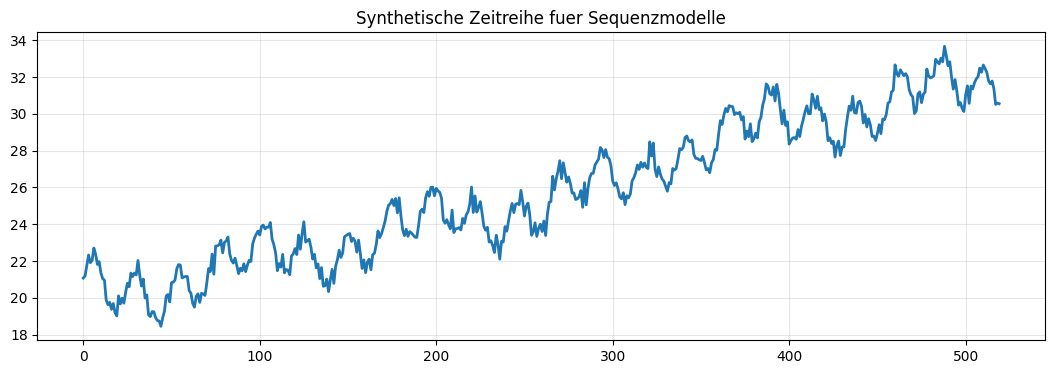

In [68]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df['time'], df['value'], linewidth=2)
ax.set_title('Synthetische Zeitreihe fuer Sequenzmodelle')
ax.grid(True, alpha=0.3)
plt.show()


In [69]:
def make_windows(frame: pd.DataFrame, feature_cols: list[str], target_col: str, lookback: int, horizon: int):
    X, y = [], []
    for end in range(lookback, len(frame) - horizon + 1):
        X.append(frame.iloc[end - lookback:end][feature_cols].to_numpy(dtype=np.float32))
        y.append(frame.iloc[end:end + horizon][target_col].to_numpy(dtype=np.float32))
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)

feature_cols = ['value', 'cycle_24_sin', 'cycle_24_cos', 'cycle_96_sin', 'cycle_96_cos']
LOOKBACK = 48
HORIZON = 12
X, y = make_windows(df, feature_cols=feature_cols, target_col='value', lookback=LOOKBACK, horizon=HORIZON)
train_end = int(len(X) * 0.7)
val_end = int(len(X) * 0.85)
X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

x_mean = X_train.mean(axis=(0, 1), keepdims=True)
x_std = X_train.std(axis=(0, 1), keepdims=True)
x_std = np.where(x_std == 0, 1, x_std)
y_mean, y_std = y_train.mean(), y_train.std()

def sx(a):
    return (a - x_mean) / x_std

def sy(a):
    return (a - y_mean) / y_std

train_ds = TensorDataset(torch.tensor(sx(X_train)), torch.tensor(sy(y_train)))
val_ds = TensorDataset(torch.tensor(sx(X_val)), torch.tensor(sy(y_val)))
test_x = torch.tensor(sx(X_test))
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)


In [70]:
class RNNForecaster(nn.Module):
    def __init__(self, cell: str, hidden_size: int = 64):
        super().__init__()
        rnn_cls = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[cell]
        self.cell = cell
        self.rnn = rnn_cls(input_size=len(feature_cols), hidden_size=hidden_size, batch_first=True)
        self.head = nn.Linear(hidden_size, HORIZON)
    def forward(self, x):
        out, hidden = self.rnn(x)
        if self.cell == 'lstm':
            hidden = hidden[0]
        return self.head(hidden[-1])

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerForecaster(nn.Module):
    def __init__(self, d_model: int = 64, nhead: int = 4):
        super().__init__()
        self.input_proj = nn.Linear(len(feature_cols), d_model)
        self.pos = PositionalEncoding(d_model, max_len=LOOKBACK)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=2)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, HORIZON))
    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos(x)
        x = self.encoder(x)
        x = x[:, -1]
        return self.head(x)


In [71]:
def train_model(model: nn.Module, epochs: int = 50, patience: int = 10):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    best_val = float('inf')
    best_state = None
    history = {'train_loss': [], 'val_loss': []}
    wait = 0

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_losses.append(criterion(model(xb), yb).item())

        tr = float(np.mean(train_losses))
        va = float(np.mean(val_losses))
        history['train_loss'].append(tr)
        history['val_loss'].append(va)
        if va < best_val:
            best_val = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, history

def predict_model(model: nn.Module):
    model.eval()
    with torch.no_grad():
        pred_s = model(test_x.to(device)).cpu().numpy()
    return pred_s * y_std + y_mean


In [72]:
builders = {
    'SimpleRNN': lambda: RNNForecaster('rnn'),
    'LSTM': lambda: RNNForecaster('lstm'),
    'GRU': lambda: RNNForecaster('gru'),
    'Transformer': lambda: TransformerForecaster(),
}

rows = []
histories = {}
predictions = {}

for name, fn in builders.items():
    model, hist = train_model(fn(), epochs=50, patience=10)
    pred = predict_model(model)
    histories[name] = hist
    predictions[name] = pred
    rows.append({
        'model': name,
        'mae': mean_absolute_error(y_test.reshape(-1), pred.reshape(-1)),
        'rmse': np.sqrt(mean_squared_error(y_test.reshape(-1), pred.reshape(-1))),
    })

pd.DataFrame(rows).sort_values('mae').reset_index(drop=True).round(4)


,model,mae,rmse
0,GRU,1.0083,1.1563
1,SimpleRNN,1.2485,1.4047
2,Transformer,1.4853,1.6882
3,LSTM,1.7199,1.8668


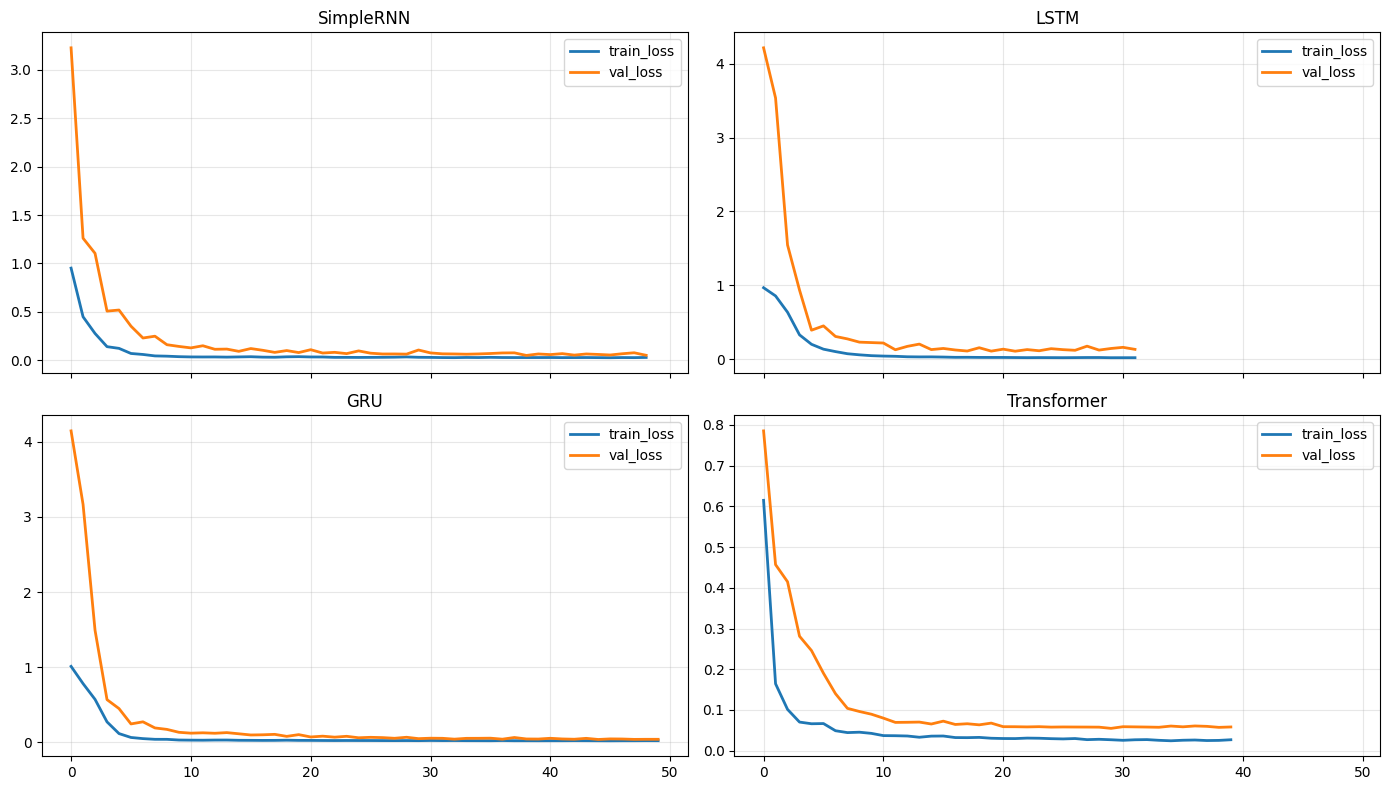

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, name in zip(axes.flat, builders.keys()):
    ax.plot(histories[name]['train_loss'], label='train_loss', linewidth=2)
    ax.plot(histories[name]['val_loss'], label='val_loss', linewidth=2)
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


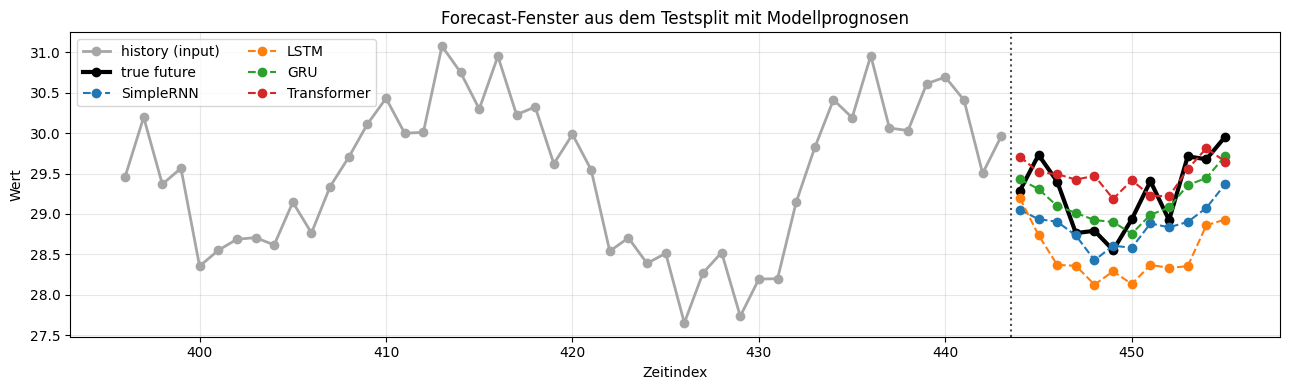

In [74]:
sample_idx = 5
window_idx = val_end + sample_idx
history_steps = np.arange(window_idx, window_idx + LOOKBACK)
future_steps = np.arange(window_idx + LOOKBACK, window_idx + LOOKBACK + HORIZON)
history_values = X_test[sample_idx, :, 0]

pd.Series({
    'sample_idx_im_testsplit': int(sample_idx),
    'fenster_index_gesamt': int(window_idx),
    'history_start': int(history_steps[0]),
    'history_end': int(history_steps[-1]),
    'future_start': int(future_steps[0]),
    'future_end': int(future_steps[-1]),
})

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(history_steps, history_values, marker='o', linewidth=2, color='0.65', label='history (input)')
ax.plot(future_steps, y_test[sample_idx], marker='o', linewidth=3, color='black', label='true future')
for name in predictions.keys():
    ax.plot(future_steps, predictions[name][sample_idx], marker='o', linestyle='--', label=name)
ax.axvline(future_steps[0] - 0.5, color='black', linestyle=':', alpha=0.7)
ax.set_title('Forecast-Fenster aus dem Testsplit mit Modellprognosen')
ax.set_xlabel('Zeitindex')
ax.set_ylabel('Wert')
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)

plt.tight_layout()
plt.show()
